# Statistics Practical Implementation with Python

### Measure of Central Tendency

In [1]:
import numpy as np

In [5]:
ages = [23, 24, 25, 20, 24, 45,50]

In [2]:
a = 1
b = 2
print(a+b)

3


In [4]:
np.mean(ages)

np.float64(26.833333333333332)

**Problem with mean**
- Outliers

In [6]:
# Median can handle outlier
print(np.median(ages))

24.0


In [9]:
# print(np.mode(ages)) Numpy hant mod fun, it can from statistic library

In [10]:
import statistics

In [14]:
print(statistics.mode(ages))
print(statistics.multimode(ages))
print(statistics.median_low(ages))
print(statistics.median_high(ages))
print(statistics.median_grouped(ages))

24
[24]
24
24
24.25


**Which plot need for delectiveing outliers ?**

In [15]:
import seaborn as sns

<Axes: >

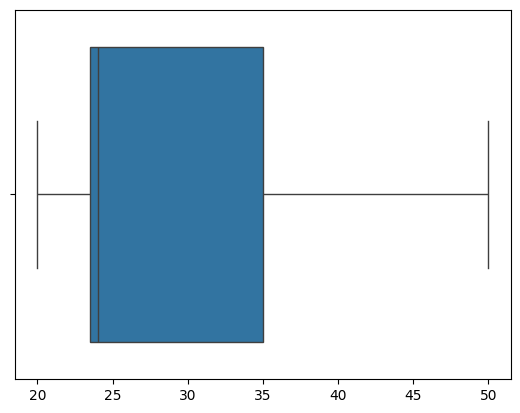

In [16]:
sns.boxplot(x=ages)


**How to get ouflier ? Five number summary **

In [17]:
q1, q3 = np.percentile(ages,[25,75])
print(q1,q3)

23.5 35.0


In [57]:
IQR = q3 - q1
lf = q1 - 1.5*(IQR) # lf - Lower fence


uf = q3 + 1.5*(IQR) # uf - Upper fence
print(lf,uf)


6.25 52.25


In [58]:
# Find IQR
q1, q3 = np.percentile(ages,[25,75])
IQR = q3 - q1
print(IQR)

3.5


**Variance**

In [19]:
ages = [23, 24, 25, 26, 27, 28, 29, 30]
statistics.variance(ages)

6

**Standard Deviation**

In [20]:
import statistics

data = [1, 2, 4, 4, 5, 8]
result = statistics.stdev(data)
print(f"Sample Standard Deviation: {result}")

Sample Standard Deviation: 2.449489742783178


**Sample Vs Polulation**

- Population : N  
- Sample : N-1

In [21]:
import math

In [23]:
# Make population or convert to Population
math.sqrt(statistics.pvariance(ages))

2.29128784747792

**Histogram**

<Axes: ylabel='Count'>

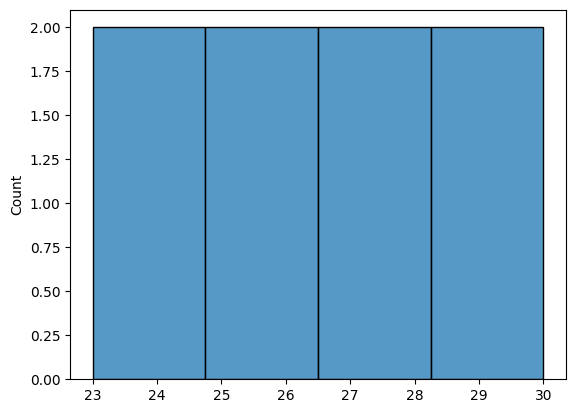

In [24]:
sns.histplot(ages)

- From histgram , we can find distribution
- kd

<Axes: ylabel='Count'>

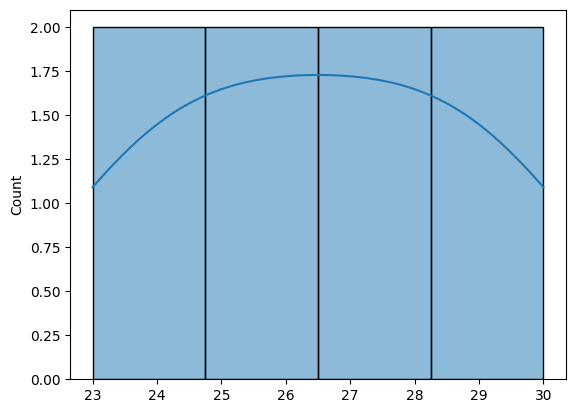

In [26]:
sns.histplot(ages, kde=True)  # just make kde=True, its shows normal distribution

**Iris dAta**

In [54]:
df = sns.load_dataset("iris")

In [30]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Count'>

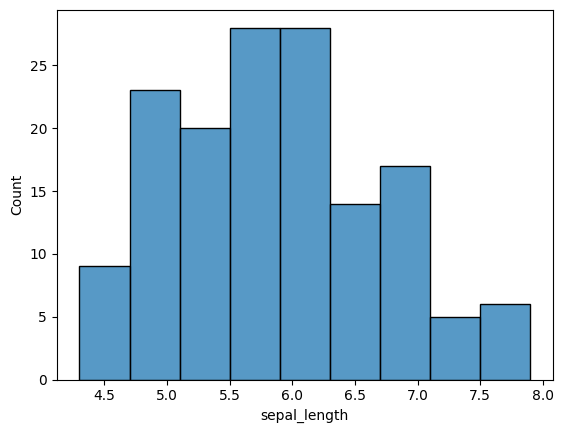

In [34]:
sns.histplot(df["sepal_length"])

<Axes: xlabel='sepal_length', ylabel='Count'>

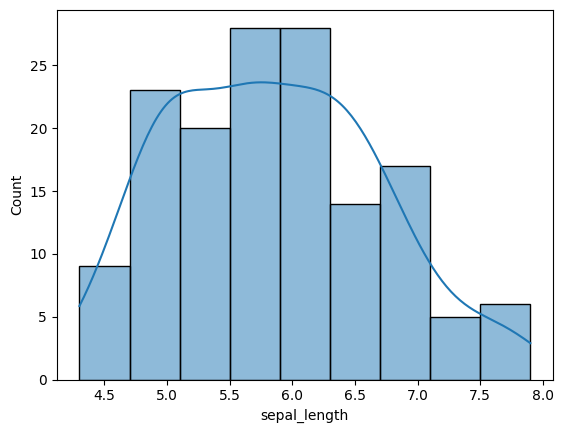

In [33]:
sns.histplot(df["sepal_length"], kde=True)

<Axes: xlabel='petal_length', ylabel='Count'>

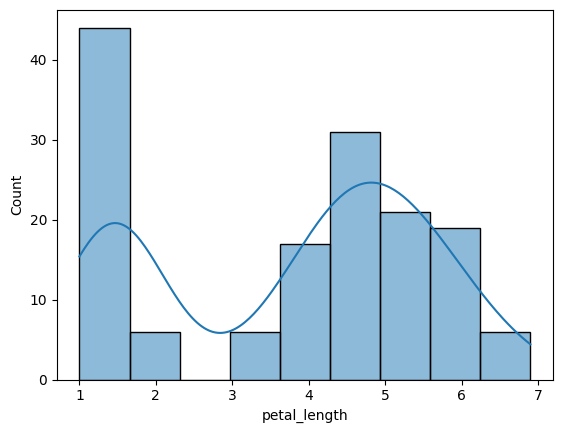

In [36]:
sns.histplot(df["petal_length"], kde=True)

<Axes: xlabel='petal_width', ylabel='Count'>

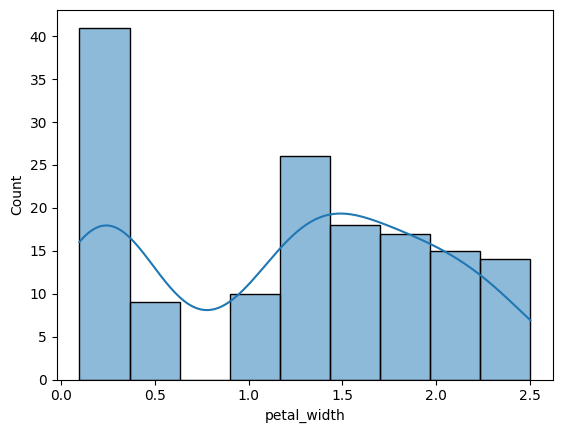

In [37]:
sns.histplot(df["petal_width"], kde=True)

<Axes: ylabel='Count'>

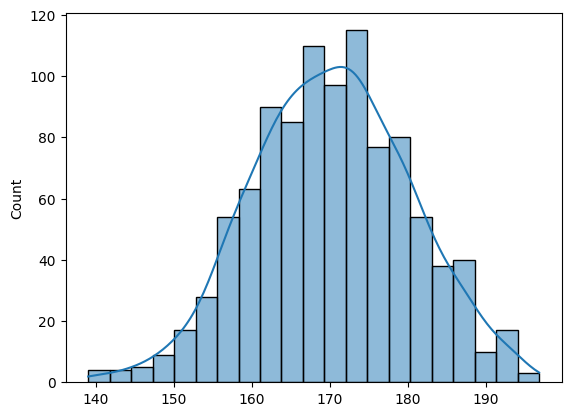

In [38]:
# Normal Distibution

s = np.random.normal(170, 10, 1000) # doc
sns.histplot(s, kde=True)

**Other Distribution**

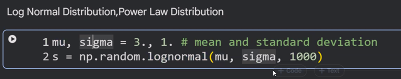

In [39]:
# Log normal Distribution

mu, sigma = 3., 1. # mean and std
s = np.random.lognormal(mu, sigma, 1000)

<Axes: ylabel='Count'>

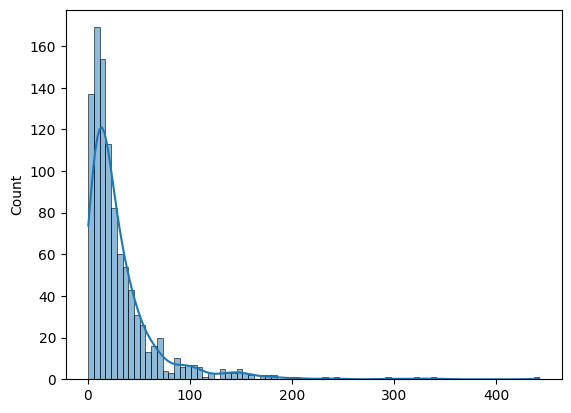

In [40]:
sns.histplot(s,kde=True)

**Log Normal Distribution to Normal Distribution - Conversion**

<Axes: ylabel='Count'>

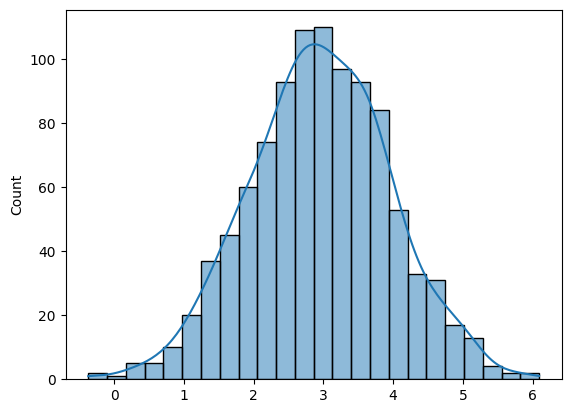

In [41]:
sns.histplot(np.log(s), kde=True)

**Q-Q Plot**

A Q–Q plot compares sample quantiles with theoretical quantiles to assess distribution normality.

✅ Correct & Clean Version (Industry-Standard)

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stat

def plot_distribution(sample):
    plt.figure(figsize=(12, 5))

    # 1️⃣ Histogram + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(sample, kde=True)
    plt.title("Histogram with KDE")

    # 2️⃣ Q-Q Plot
    plt.subplot(1, 2, 2)
    stat.probplot(sample, dist="norm", plot=plt)
    plt.title("Q-Q Plot (Normal Distribution)")

    plt.tight_layout()
    plt.show()


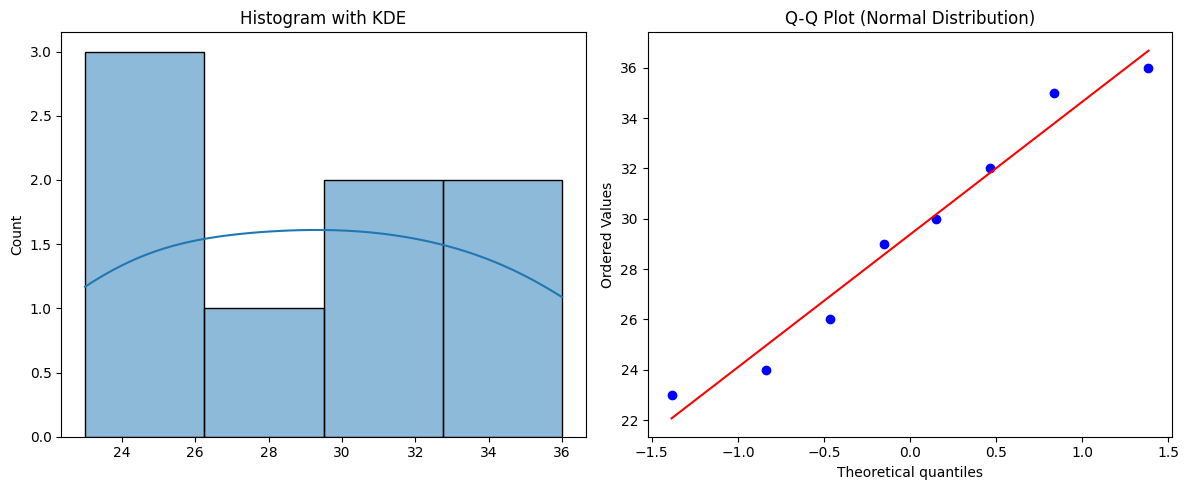

In [53]:
# Call the function

plot_distribution(sample)


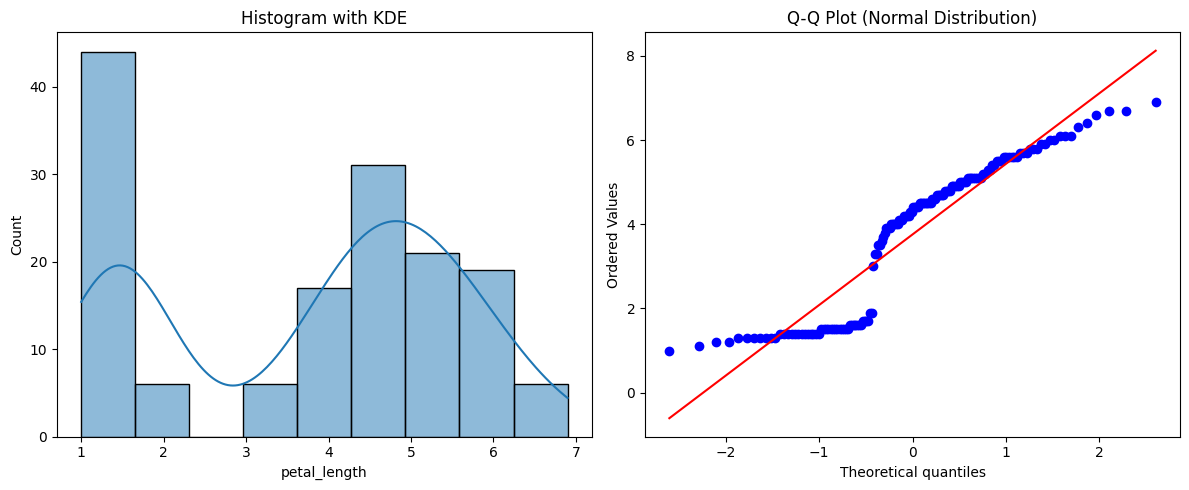

In [56]:
# Passing Iris data to plot_distribution def
plot_distribution(df['petal_length'])

📌 What each plot tells you (very important for learning)


🔹 Histogram + KDE

- Shape of data
- Skewness (left / right)
- Peaks & spread

🔹 Q–Q Plot

- Checks normality
- Points on straight line → normal distribution
- Curved or S-shape → skewed / heavy-tailed

🎯 When to use this (real-world)

- Before applying IQR
- Before Z-score
- Before choosing ML models
- Feature engineering decisions

🧠 One-line exam / interview answer
- A Q–Q plot compares sample quantiles with theoretical quantiles to assess distribution normality.

## Correlation

- Area, nroom, price

- Input/Features/ columm: Area, No of Rooms

- Target: Price - which to be predicted

**Why Correation**

- Need to find correlation for proper prediction , without relation/pattern prediction not possible, that why correlation finding matters
- You might have numeous input/ features , need to find relevant ones
- Need numerial data (Tips data), not Iris data
- Its not possible to find correation between `Numeric data` & `Categorial data`

In [50]:
df = sns.load_dataset("tips") # Corretation find not applied for categorial data
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [51]:
df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


- Total Bill : Total Bill --> 100%
- Total Bill : Tip -- 67% (Increase to Increease)
- Total bill :  Size -- 59% correlation (less correted than Tip)

## Chapter 2: Five Number Summary

The Five-Number Summary is a simple but very powerful statistical concept

📊 What is the Five-Number Summary?

- It describes a dataset using five key values:

| Component               | Meaning                |
| ----------------------- | ---------------------- |
| **Minimum**             | Smallest value         |
| **Q1 (First Quartile)** | 25% of data below this |
| **Median (Q2)**         | 50% of data below this |
| **Q3 (Third Quartile)** | 75% of data below this |
| **Maximum**             | Largest value          |


📌 Example Dataset

In [59]:
data = [2, 4, 7, 10, 12, 15, 18, 20]

Five-Number Summary:

```bash
Min = 2
Q1 = 6.25
Median = 11
Q3 = 16.25
Max = 20
```

🧠 Why it is important (real-world use)
```bash
✔ Detect outliers
✔ Understand spread & skewness
✔ Foundation for IQR method
✔ Used in Boxplots
✔ Essential for EDA before ML
```

🧪 Python Code (clean & practical)

In [61]:
import numpy as np


data = [2, 4, 6, 8, 10, 12, 18, 20]

five_num = {
    "Min": np.min(data),
    "Q1":np.percentile(data, 25),
    "Median": np.percentile(data, 50),
    "Q3":np.percentile(data, 75),
    "Maxium": np.max(data)
}

five_num

{'Min': np.int64(2),
 'Q1': np.float64(5.5),
 'Median': np.float64(9.0),
 'Q3': np.float64(13.5),
 'Maxium': np.int64(20)}

📦 Relation with IQR

```bash

IQR = Q3 − Q1
------------------
Lower Bound = Q1 − 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR

```

🎓 Exam / Interview One-liner:

The five-number summary gives a concise description of a dataset’s distribution using minimum, quartiles, median, and maximum.